# Long-Only ML Strategy Notebook

This notebook is organized as a research workflow rather than a single backtest script.

The early sections build the universe, labels, models, and scored panel. The later sections ask narrower questions about timing, ranking, component roles, and robustness so we can tell where any edge is really coming from.


## Research Roadmap

Implemented now:
- `A-D`: build the research dataset, labels, base models, and scoring panel
- `H-I`: compare deterministic score-family rules (`raw3` vs `raw_pct6`) under fixed execution logic
- `J`: run paper-inspired tests for cross-sectional ranking, signal/composite roles, timing, and robustness

How to read the notebook:
- `A-D` tell you what the model is trained on and what inputs the later experiments are using
- `H-I` tell you which score family is the better tradable rule
- `J` tells you whether the apparent edge comes from timing value, ranking value, portfolio construction, or fragile specification choices


## A) Research Setup


In [1]:
import os
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import django
from django.apps import apps
from django.db.models import Q

# Jupyter kernels often run an async loop; allow sync ORM calls in this notebook context.
os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "settings")
if not apps.ready:
    django.setup()

from fmp.models import Symbol
from features.feature_builders import build_price_technical_features
from features.views import _load_adjusted_prices
from pipeline.api import (
    build_fundamental_dataframe,
    build_macro_dataframe,
    build_label_dataframe,
)
from data.preparation import MLDatasetConfig, prepare_ml_dataset
from ml.raw_stack import train_rf_models, train_ae
from backtest.raw_stack import (
    StrategyCase,
    ProbabilityColumnConfig,
    enrich_scored_panel,
    make_backtest_panel,
    make_exec_cfg,
    run_case as run_eval_case,
    strategy_diagnostics,
    build_anchored_fold,
)
from ml.rl.common import RLConfig, make_rebalance_mask, backtest_strategy_per_stock_discrete
from backtest.latest import run_panel_prediction_custom, make_autoencoder_familiarity_predictor
from backtest.backtest import backtest_panel
from backtest.strategies.benchmark import BuyAndHoldEqualWeightStrategy
from pipeline.universe_selection import DEFAULT_US_EXCHANGES, resolve_symbol_universe

pd.set_option("display.max_columns", 200)


def _build_technical_dataframe_from_django(
    *,
    symbols,
    start_date=None,
    end_date=None,
):
    start_ts = pd.Timestamp(start_date) if start_date is not None else None
    end_ts = pd.Timestamp(end_date) if end_date is not None else None

    frames = []
    feature_cols = []

    for sym in symbols:
        code = str(sym).strip().upper()
        if not code:
            continue

        symbol_obj = Symbol.objects.filter(symbol__iexact=code).only("id", "symbol").first()
        if symbol_obj is None:
            continue

        df_prices = _load_adjusted_prices(
            symbol_obj,
            start_ts.date() if start_ts is not None else None,
            end_ts.date() if end_ts is not None else None,
        )
        if df_prices.empty:
            continue

        built = build_price_technical_features(code, df_prices)
        if built.df.empty:
            continue

        px = df_prices[["open", "high", "low", "close", "volume"]].copy()
        px["symbol"] = code
        px = px.reset_index().set_index(["date", "symbol"]).sort_index()

        panel = px.join(built.df[built.feature_cols], how="left")
        frames.append(panel)

        for col in built.feature_cols:
            if col not in feature_cols:
                feature_cols.append(col)

    if not frames:
        empty_index = pd.MultiIndex(levels=[[], []], codes=[[], []], names=["date", "symbol"])
        return pd.DataFrame(index=empty_index), feature_cols

    technical_df = pd.concat(frames, axis=0).sort_index()
    if technical_df.index.has_duplicates:
        technical_df = technical_df[~technical_df.index.duplicated(keep="last")]

    return technical_df, feature_cols


# ------------------------------
# Global Config (single source of truth)
# ------------------------------
APP_CFG = {
    "dates": {
        "train_cutoff": "2020-12-31",
        "bt_start": "2021-01-01",
        "bt_end": "2025-12-31",
        "data_start": "1900-01-01",
    },
    "universe": {
        "country": "US",
        "exchanges": list(DEFAULT_US_EXCHANGES),
        "min_market_cap": 100_000_000_000.0,
        "exclude_pooled_vehicles": True,
        "size": None,  # None => full DB-matched universe
    },
    "runtime": {
        "cache_enabled": True,
        "fast_rl_metrics": True,
    },
    "costs": {
        "fee_bps": 5.0,
        "slippage_bps": 5.0,
    },
    "strategy": {
        "top_k": 20,
        "rebalance_freq": "W",   # D, W, M
        "gate_q": 0.50,
        "component_threshold": 0.50,
        "gross": 0.8,
    },
    "labels": {
        "k_params": {"YE": [1, 2, 4, 8]},
        "use_sample_weight": True,
        "alpha": 4.0,
        "r_clip": 0.10,
        "horizon_balance": True,
    },
    "probability_columns": {
        "buy_col": "clf__prob_1",
        "short_col": None,
        "infer_short_from_buy": True,
    },
    "rl": {
        "lookback_window": 10,
        "rebalance_freq": None,
        "initial_balance": 100000.0,
        "ppo_seed": 42,
        "episodes_per_symbol": 3,
        "drawdown_penalty_lambda": 0.10,
        "force_buy_sell_everything": False,
        "include_rank_features": True,
        "selection_score_col": "buy_score_mean_raw3",
    },
}


def build_feature_diagnostics(feature_df):
    work = feature_df.reset_index().copy()
    feature_cols = [
        col for col in work.columns
        if col not in {"date", "symbol"} and pd.api.types.is_numeric_dtype(work[col])
    ]
    if not feature_cols:
        empty = pd.DataFrame()
        return empty, empty
    coverage = (
        work[feature_cols].notna().mean().mul(100.0).sort_values(ascending=False)
        .rename("coverage_pct").reset_index().rename(columns={"index": "feature"})
    )
    overview = pd.DataFrame([
        {
            "rows": int(len(work)),
            "symbols": int(work["symbol"].nunique()) if "symbol" in work.columns else 0,
            "numeric_feature_count": int(len(feature_cols)),
            "dense_features_ge_50pct": int((coverage["coverage_pct"] >= 50.0).sum()),
            "mid_features_10_to_50pct": int(((coverage["coverage_pct"] >= 10.0) & (coverage["coverage_pct"] < 50.0)).sum()),
            "sparse_features_below_10pct": int((coverage["coverage_pct"] < 10.0).sum()),
        }
    ])
    low_coverage = coverage.sort_values("coverage_pct", ascending=True).head(25).reset_index(drop=True)
    return overview, low_coverage


def build_label_diagnostics(label_df):
    work = label_df.copy()
    if isinstance(work.index, pd.MultiIndex):
        index_names = list(work.index.names)
        if "date" in index_names or "symbol" in index_names:
            work = work.reset_index()
    elif getattr(work.index, "name", None) in {"date", "symbol"}:
        work = work.reset_index()
    if work.empty:
        empty = pd.DataFrame()
        return empty, empty, empty
    if "date" in work.columns:
        work["date"] = pd.to_datetime(work["date"], errors="coerce")
    if "symbol" in work.columns:
        work["symbol"] = work["symbol"].astype(str).str.strip().str.upper()
    if "trade_return" in work.columns:
        work["trade_return"] = pd.to_numeric(work["trade_return"], errors="coerce")
    horizon_col = "horizon" if "horizon" in work.columns else ("k" if "k" in work.columns else None)
    summary = pd.DataFrame([
        {
            "label_rows": int(len(work)),
            "symbols": int(work["symbol"].nunique()) if "symbol" in work.columns else 0,
            "unique_dates": int(work["date"].nunique()) if "date" in work.columns else 0,
            "avg_trade_return": float(work["trade_return"].mean()) if "trade_return" in work.columns else np.nan,
            "median_trade_return": float(work["trade_return"].median()) if "trade_return" in work.columns else np.nan,
            "positive_trade_return_rows": int((work["trade_return"] > 0).sum()) if "trade_return" in work.columns else 0,
        }
    ])
    by_horizon = pd.DataFrame()
    if horizon_col is not None:
        by_horizon = (
            work.groupby(horizon_col)
            .agg(
                label_rows=(horizon_col, "size"),
                unique_symbols=("symbol", "nunique"),
                unique_dates=("date", "nunique"),
                avg_trade_return=("trade_return", "mean"),
                median_trade_return=("trade_return", "median"),
            )
            .reset_index()
            .sort_values(horizon_col)
            .reset_index(drop=True)
        )
    by_symbol = pd.DataFrame()
    if "symbol" in work.columns:
        by_symbol = (
            work.groupby("symbol")
            .agg(
                label_rows=("symbol", "size"),
                unique_dates=("date", "nunique"),
                avg_trade_return=("trade_return", "mean"),
                median_trade_return=("trade_return", "median"),
            )
            .reset_index()
            .sort_values(["label_rows", "avg_trade_return"], ascending=[False, False])
            .reset_index(drop=True)
        )
    return summary, by_horizon, by_symbol




## B) Universe And Feature Build


In [2]:
# 1) Django setup + universe + feature panel
os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "settings")
if not apps.ready:
    django.setup()

universe = tuple(
    resolve_symbol_universe(
        min_market_cap=float(APP_CFG["universe"]["min_market_cap"]),
        country=str(APP_CFG["universe"]["country"]),
        exchanges=list(APP_CFG["universe"]["exchanges"]),
        exclude_pooled_vehicles=bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
        limit=APP_CFG["universe"]["size"],
    )
)

if APP_CFG["universe"]["size"] is not None:
    universe = tuple(universe[: int(APP_CFG["universe"]["size"])])

if len(universe) == 0:
    raise RuntimeError("Django Symbol query returned 0 symbols for the configured filters.")

START_DATE = APP_CFG["dates"]["data_start"]
END_DATE = pd.Timestamp(APP_CFG["dates"]["bt_end"]).strftime("%Y-%m-%d")

technical_df, technical_cols = _build_technical_dataframe_from_django(
    symbols=universe,
    start_date=START_DATE,
    end_date=END_DATE,
)
if technical_df.empty:
    raise RuntimeError("No technical rows were built from Django prices_div_adj data.")

# build_fundamental_dataframe/build_macro_dataframe are DB-backed through features/* modules.
ctx = SimpleNamespace(api_key="")
fund_df, fund_cols = build_fundamental_dataframe(
    ctx=ctx,
    symbols=universe,
    start_date=START_DATE,
    end_date=END_DATE,
    target_index=technical_df.index,
    daily_prices=technical_df,
    verbose=False,
)
macro_df, macro_cols = build_macro_dataframe(
    ctx=ctx,
    start_date=START_DATE,
    end_date=END_DATE,
    target_index=technical_df.index,
    verbose=False,
)

final_df = pd.concat([technical_df, fund_df, macro_df], axis=1).sort_index()
universe_diagnostics_df = pd.DataFrame([
    {
        "country": APP_CFG["universe"]["country"],
        "exchanges": ", ".join(APP_CFG["universe"]["exchanges"]),
        "min_market_cap": float(APP_CFG["universe"]["min_market_cap"]),
        "exclude_pooled_vehicles": bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
        "resolved_symbol_count": int(len(universe)),
        "sample_symbols": ", ".join(list(universe)[:25]),
    }
])
feature_diagnostics_overview, feature_low_coverage = build_feature_diagnostics(final_df)

print("Universe size:", len(universe))
print("Feature panel shape:", final_df.shape)
print("Feature date range:", final_df.index.get_level_values("date").min().date(), "->", final_df.index.get_level_values("date").max().date())

/Users/johnnylee/PycharmProjects/optimal_trader/data/pit.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sparse = sparse_df.reset_index()
/Users/johnnylee/PycharmProjects/optimal_trader/data/pit.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sparse = sparse_df.reset_index()


Universe size: 114
Feature panel shape: (1122782, 196)
Feature date range: 1962-01-02 -> 2025-12-31


## C) Label Library And Base Models (Pre-2021 Cutoff)


In [3]:
# 2) Train models using data <= train_cutoff (pre-bt)
TRAIN_CUTOFF_TS = pd.Timestamp(APP_CFG["dates"]["train_cutoff"])
train_mask = final_df.index.get_level_values("date") <= TRAIN_CUTOFF_TS
features_train = final_df.loc[train_mask].copy()

symbols_in_train = set(technical_df.loc[technical_df.index.get_level_values("date") <= TRAIN_CUTOFF_TS].index.get_level_values("symbol"))
daily_map_train = {
    s: technical_df.xs(s, level="symbol").loc[:TRAIN_CUTOFF_TS].copy()
    for s in universe
    if s in symbols_in_train
}

K_PARAMS = dict(APP_CFG["labels"]["k_params"])
EXECUTION_PARAMS = {
    "price_col": "close",
    "fee_bps": float(APP_CFG["costs"]["fee_bps"]),
    "slippage_bps": float(APP_CFG["costs"]["slippage_bps"]),
}
WEIGHTING_PARAMS = {
    "use_sample_weight": bool(APP_CFG["labels"]["use_sample_weight"]),
    "alpha": float(APP_CFG["labels"]["alpha"]),
    "r_clip": float(APP_CFG["labels"]["r_clip"]),
    "horizon_balance": bool(APP_CFG["labels"]["horizon_balance"]),
}

label_df_train = build_label_dataframe(
    daily_by_symbol=daily_map_train,
    k_params=K_PARAMS,
    execution_params=EXECUTION_PARAMS,
    weighting=WEIGHTING_PARAMS,
    add_rank_labels=True,
    verbose=False,
)

train_df, raw_feature_list, _ = prepare_ml_dataset(
    features_df=features_train,
    labels_df=label_df_train,
    target_cols=["target", "trade_return", "trade_duration_days"],
    weight_col="sample_weight",
    config=MLDatasetConfig(drop_nan_features=False),
    verbose=True,
)

trade_return_values = pd.to_numeric(train_df["trade_return"], errors="coerce")
train_df["trade_return_pct_target"] = trade_return_values.rank(pct=True, method="average")

rf_bundle = train_rf_models(
    train_df,
    raw_feature_list,
    split_ratio=1.0,
    classifier_target_col="target",
    ranking_target_col="rank_y",
    classifier_market_position_col=None,
    train_trade_return_model=True,
    trade_return_target_col="trade_return_pct_target",
    train_duration_model=False,
)

clf_raw = rf_bundle.clf
reg_raw = rf_bundle.trade_return_reg if rf_bundle.trade_return_reg is not None else rf_bundle.ranking_reg

ae_raw, ae_numeric_cols = train_ae(train_df, raw_feature_list)
label_diagnostics_summary, label_diagnostics_by_horizon, label_diagnostics_by_symbol = build_label_diagnostics(label_df_train)
train_objective_df = pd.DataFrame([
    {
        "train_window": f"{APP_CFG['dates']['data_start']} to {APP_CFG['dates']['train_cutoff']}",
        "backtest_window": f"{APP_CFG['dates']['bt_start']} to {APP_CFG['dates']['bt_end']}",
        "symbols_requested": int(len(universe)),
        "label_k_params": str(APP_CFG['labels']['k_params']),
        "training_rows": int(len(train_df)),
        "feature_count": int(len(raw_feature_list)),
        "classifier_target": "target",
        "regressor_target": "trade_return_pct_target",
        "autoencoder_numeric_cols": int(len(ae_numeric_cols)),
    }
])

print("Train rows:", len(train_df))
print("Train date max:", pd.to_datetime(train_df.index.get_level_values('date')).max().date())


--- Preparing ML Training Dataset ---
  - Final Training Rows: 70,403
  - Active Features:     196
  - Targets:             ['target', 'trade_return', 'trade_duration_days']
  - Sample Weight Col:   sample_weight

  DIAGNOSTIC: SKLEARN RANDOM FOREST CLASSIFIER (TEST RESULTS)
DATASET & SPLIT:
  - Total Observations: 70,403
  - Split Mode:         In-sample eval (no internal holdout split)
  - Features:           195 numeric (filtered 1 strings)

CLASS DISTRIBUTION (Mapping: {0: '0', 1: '1'}):
               Train Set              Test Set
  -        0:  35,078 (49.8%)    35,078 (49.8%)
  -        1:  35,325 (50.2%)    35,325 (50.2%)

TEST PERFORMANCE:
  - Accuracy:           98.86%
  - ROC AUC:            0.9994

CONFUSION MATRIX (Test Set):
            Pred       0 Pred       1 
True       0:        34782          296 
True       1:          506        34819 

TOP 10 FEATURES:
  - px__dist_sma_10: 0.0977
  - px__pos_in_channel_10: 0.0730
  - px__bb_pos_10: 0.0672
  - px__bb_pos_20: 0.0

## D) Score Panel And Experiment Inputs (History + 2021-2025 OOS)



In [4]:
# 3) Score panel for model backtest + RL (with pre-cutoff history)
BT_START_TS = pd.Timestamp(APP_CFG["dates"]["bt_start"])
BT_END_TS = pd.Timestamp(APP_CFG["dates"]["bt_end"])
DATA_START_TS = pd.Timestamp(APP_CFG["dates"]["data_start"])
prob_cfg = ProbabilityColumnConfig(**APP_CFG["probability_columns"])

panel_for_scoring = final_df.loc[
    (final_df.index.get_level_values("date") >= DATA_START_TS)
    & (final_df.index.get_level_values("date") <= BT_END_TS)
].copy()

if panel_for_scoring.empty:
    raise RuntimeError("No feature rows in scoring panel.")

ae_predict = make_autoencoder_familiarity_predictor(ae_numeric_cols)

scored_panel_all = run_panel_prediction_custom(
    train_data=panel_for_scoring,
    model_specs=[
        {"model": clf_raw, "pred_col": "clf", "include_class_probs": True},
        {"model": reg_raw, "pred_col": "ranking"},
        {"model": ae_raw, "pred_col": "ae_familiarity", "predict_fn": lambda df, m: ae_predict(df, m)},
    ],
    market_position_value=None,
    combine_scores_fn=lambda df: pd.to_numeric(df[prob_cfg.buy_col], errors="coerce").fillna(0.0)
    * pd.to_numeric(df["ranking"], errors="coerce").fillna(0.0)
    * pd.to_numeric(df["ae_familiarity"], errors="coerce").fillna(1.0),
    row_filter_fn=None,
    round_decimals=None,
)

scored_panel_all = enrich_scored_panel(scored_panel_all, prob_config=prob_cfg)
score_columns = [
    col for col in [
        "buy_score_raw",
        "buy_score_pct_product",
        "buy_score_pct_mean",
        "buy_score_mean_raw3",
        "buy_score_mean_raw_pct6",
        "buy_score",
        "prob_buy_pct",
        "pred_rf_reg_pct",
        "ae_familiarity_pct",
    ] if col in scored_panel_all.columns
]
print("Available score columns:", score_columns)
bt_panel_all = make_backtest_panel(
    scored_panel=scored_panel_all,
    technical_df=technical_df,
    start=DATA_START_TS,
    end=BT_END_TS,
)

bt_panel_5y = bt_panel_all.loc[
    (bt_panel_all.index.get_level_values("date") >= BT_START_TS)
    & (bt_panel_all.index.get_level_values("date") <= BT_END_TS)
].copy()

print("Backtest panel shape (all years for RL train/eval):", bt_panel_all.shape)
print("Backtest panel shape (5-year OOS display):", bt_panel_5y.shape)
print(
    "Backtest date range:",
    bt_panel_all.index.get_level_values("date").min().date(),
    "->",
    bt_panel_all.index.get_level_values("date").max().date(),
)


Available score columns: ['buy_score_raw', 'buy_score_pct_product', 'buy_score_pct_mean', 'buy_score_mean_raw3', 'buy_score_mean_raw_pct6', 'buy_score', 'prob_buy_pct', 'pred_rf_reg_pct', 'ae_familiarity_pct']
Backtest panel shape (all years for RL train/eval): (1122782, 221)
Backtest panel shape (5-year OOS display): (137278, 221)
Backtest date range: 1962-01-02 -> 2025-12-31


## E) Shared Execution Config



In [5]:
# 4) Strategy/backtest config (module-native)

cfg = make_exec_cfg(
    fee_bps=float(APP_CFG["costs"]["fee_bps"]),
    slippage_bps=float(APP_CFG["costs"]["slippage_bps"]),
    execution_mode="rl_env",
)

print("Execution config:")
display(cfg)


Execution config:


ExecutionConfig(price_col='close', fee_bps=5.0, slippage_bps=5.0, use_lagged_weights=True, turnover_half_l1=True, execution_mode='rl_env')

## F) Universe And Feature Diagnostics



In [6]:
# 5) Feature and universe diagnostics
print("Equity universe screen")
display(universe_diagnostics_df)
print("Feature diagnostics overview")
display(feature_diagnostics_overview)
print("Lowest-coverage numeric features")
display(feature_low_coverage)


Equity universe screen


,country,exchanges,min_market_cap,exclude_pooled_vehicles,resolved_symbol_count,sample_symbols
0,US,"NASDAQ, NYSE, AMEX",1.000000e+11,True,114,"GOOG, AVGO, BRK-B, BRK-A, WMT, LLY, JPM, XOM, ..."


Feature diagnostics overview


,rows,symbols,numeric_feature_count,dense_features_ge_50pct,mid_features_10_to_50pct,sparse_features_below_10pct
0,1122782,114,195,194,1,0


Lowest-coverage numeric features


,feature,coverage_pct
0,USTMonth2,17.420835
1,InflationRate,50.776731
2,USTMonth1,53.416246
3,USTYear20,67.235492
4,GrahamNumber,68.868489
5,PriceToFreeCashFlowRatio,71.625837
6,PriceToOperatingCashFlowRatio,71.664312
7,USTYear3,73.067523
8,USTMonth3,73.067523
9,USTYear2,73.067523


## G) Label Diagnostics And Training Summary



In [7]:
# 6) Label and training diagnostics
print("Training objective")
display(train_objective_df)
print("Label diagnostics summary")
display(label_diagnostics_summary)
print("Labels by horizon")
display(label_diagnostics_by_horizon)
print("Labels by symbol")
display(label_diagnostics_by_symbol)


Training objective


,train_window,backtest_window,symbols_requested,label_k_params,training_rows,feature_count,classifier_target,regressor_target,autoencoder_numeric_cols
0,1900-01-01 to 2020-12-31,2021-01-01 to 2025-12-31,114,"{'YE': [1, 2, 4, 8]}",70403,196,target,trade_return_pct_target,195


Label diagnostics summary


,label_rows,symbols,unique_dates,avg_trade_return,median_trade_return,positive_trade_return_rows
0,70403,108,13097,0.232893,0.156224,70403


Labels by horizon


,horizon,label_rows,unique_symbols,unique_dates,avg_trade_return,median_trade_return
0,YE_k1,5770,108,3230,0.559196,0.422552
1,YE_k2,7667,107,4583,0.385764,0.292872
2,YE_k4,15329,106,7555,0.250991,0.188809
3,YE_k8,41637,106,12076,0.152862,0.114279


Labels by symbol


,symbol,label_rows,unique_dates,avg_trade_return,median_trade_return
0,IBM,1069,944,0.170459,0.123280
1,XOM,1066,944,0.136608,0.100566
2,GE,1060,944,0.173679,0.127813
3,MRK,1059,944,0.176001,0.134022
4,HWM,1058,944,0.235271,0.171633
...,...,...,...,...,...
103,CRWD,37,32,0.876999,0.333761
104,UBER,37,32,0.467200,0.253527
105,PLTR,12,12,0.782894,0.208727
106,BNH,4,4,0.035743,0.036164


## H) Signal Rule Benchmark Setup



In [8]:
# 6) Benchmark horizon config (RL disabled for this notebook run)

BENCHMARK_CFG = {
    "years": list(range(pd.Timestamp(APP_CFG["dates"]["bt_start"]).year, pd.Timestamp(APP_CFG["dates"]["bt_end"]).year + 1)),
    "rebalance_freq": APP_CFG["rl"].get("rebalance_freq"),
    "component_threshold": float(APP_CFG["strategy"]["component_threshold"]),
    "selection_score_col": str(APP_CFG["rl"].get("selection_score_col", "buy_score")),
    "score_variants": {
        "raw3": "buy_score_mean_raw3",
        "raw_pct6": "buy_score_mean_raw_pct6",
    },
    "initial_balance": float(APP_CFG["rl"]["initial_balance"]),
    "fee_bps": float(APP_CFG["costs"]["fee_bps"]),
    "slippage_bps": float(APP_CFG["costs"]["slippage_bps"]),
}
FROZEN_BT_YEARS = list(BENCHMARK_CFG["years"])
print("RL training disabled. Running signal-allocation benchmarks only.")
display(pd.DataFrame([BENCHMARK_CFG]))


RL training disabled. Running signal-allocation benchmarks only.


,years,rebalance_freq,component_threshold,selection_score_col,score_variants,initial_balance,fee_bps,slippage_bps
0,"[2021, 2022, 2023, 2024, 2025]",None,0.5,buy_score_mean_raw3,"{'raw3': 'buy_score_mean_raw3', 'raw_pct6': 'b...",100000.0,5.0,5.0


## I) Signal Rule Benchmark Results



In [9]:
# 7) Benchmark panel for signal-only portfolio rules

benchmark_index = pd.DatetimeIndex(sorted(pd.Index(bt_panel_5y.index.get_level_values("date")).unique()))
print("Benchmark panel shape:", bt_panel_5y.shape)
print("Benchmark date range:", benchmark_index.min().date(), "->", benchmark_index.max().date())
display(pd.DataFrame([
    {
        "rows": int(len(bt_panel_5y)),
        "symbols": int(bt_panel_5y.index.get_level_values("symbol").nunique()),
        "decision_dates": int(len(benchmark_index)),
        "selection_score_col": BENCHMARK_CFG["selection_score_col"],
        "score_variants": str(BENCHMARK_CFG["score_variants"]),
        "score_col_exists": bool(BENCHMARK_CFG["selection_score_col"] in bt_panel_5y.columns),
        "available_score_columns": ", ".join([
            c for c in [
                "buy_score_raw",
                "buy_score_pct_product",
                "buy_score_pct_mean",
                "buy_score_mean_raw3",
                "buy_score_mean_raw_pct6",
                "buy_score",
            ] if c in bt_panel_5y.columns
        ]),
        "rebalance_freq": BENCHMARK_CFG["rebalance_freq"],
        "component_threshold": BENCHMARK_CFG["component_threshold"],
    }
]))


Benchmark panel shape: (137278, 221)
Benchmark date range: 2021-01-04 -> 2025-12-31


,rows,symbols,decision_dates,selection_score_col,score_variants,score_col_exists,available_score_columns,rebalance_freq,component_threshold
0,137278,114,1255,buy_score_mean_raw3,"{'raw3': 'buy_score_mean_raw3', 'raw_pct6': 'b...",True,"buy_score_raw, buy_score_pct_product, buy_scor...",None,0.5


### I.1 Benchmark Helpers

This helper block defines the deterministic backtest rules used in the notebook. The goal is to keep the execution logic fixed so we can compare score families fairly.


In [10]:
# 8) Signal-only buy_score rules + buy-and-hold benchmark
def summarize_curve(returns, years, mode):
    total_return_pct = float((returns.add(1.0).cumprod().iloc[-1] - 1.0) * 100.0) if len(returns) else np.nan
    sharpe = float((returns.mean() / returns.std(ddof=0)) * np.sqrt(252.0)) if len(returns) and returns.std(ddof=0) > 1e-12 else np.nan
    equity = (1.0 + returns).cumprod()
    max_drawdown_pct = float((((equity / equity.cummax()) - 1.0).min()) * 100.0) if len(equity) else np.nan
    yearly_rows = []
    for yr in years:
        yret = returns.loc[(returns.index >= pd.Timestamp(f"{yr}-01-01")) & (returns.index <= pd.Timestamp(f"{yr}-12-31"))]
        yeq = (1.0 + yret).cumprod()
        yearly_rows.append({
            "mode": mode,
            "test_year": int(yr),
            "total_return_pct": float((yeq.iloc[-1] - 1.0) * 100.0) if len(yeq) else np.nan,
            "sharpe": float((yret.mean() / yret.std(ddof=0)) * np.sqrt(252.0)) if len(yret) and yret.std(ddof=0) > 1e-12 else np.nan,
            "max_drawdown_pct": float((((yeq / yeq.cummax()) - 1.0).min()) * 100.0) if len(yeq) else np.nan,
        })
    return {
        "total_return_pct": total_return_pct,
        "sharpe": sharpe,
        "max_drawdown_pct": max_drawdown_pct,
        "yearly_df": pd.DataFrame(yearly_rows),
    }


def run_simple_buy_score_rule(
    *,
    panel,
    score_col,
    component_cols,
    component_threshold,
    price_col,
    rebalance_freq,
    initial_balance,
    fee_bps,
    slippage_bps,
):
    symbols = sorted(panel.index.get_level_values("symbol").unique())

    def pivot(col):
        return (
            panel[[col]]
            .reset_index()
            .pivot(index="date", columns="symbol", values=col)
            .reindex(columns=symbols)
            .sort_index()
        )

    score = pivot(score_col).shift(1)
    close = pivot(price_col)
    common_dates = score.index.intersection(close.index)
    score = score.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    close = close.loc[common_dates].replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)

    score_valid = score.notna() & np.isfinite(score)
    eligible = (score_valid & close.gt(0.0)).fillna(False)
    for col in component_cols:
        component = pivot(col).shift(1).reindex(index=common_dates, columns=symbols)
        component = component.replace([np.inf, -np.inf], np.nan)
        component_valid = component.notna() & np.isfinite(component)
        eligible &= (component.gt(float(component_threshold)) & component_valid).fillna(False)

    rebalance_mask = make_rebalance_mask(common_dates, rebalance_freq)
    action_type = np.zeros((len(common_dates), len(symbols)), dtype=int)
    held_idx = set()

    for t, dt in enumerate(common_dates):
        if not bool(rebalance_mask[t]):
            continue
        score_t = score.loc[dt]
        elig_t = eligible.loc[dt]
        ranked = score_t[elig_t].sort_values(ascending=False, kind="stable")
        selected_syms = list(ranked.index)
        selected_idx = {symbols.index(sym) for sym in selected_syms}
        enter_idx = sorted(selected_idx - held_idx)
        exit_idx = sorted(held_idx - selected_idx)
        if enter_idx:
            action_type[t, enter_idx] = 1
        if exit_idx:
            action_type[t, exit_idx] = 2
        held_idx = selected_idx

    eq, ret, cash, details = backtest_strategy_per_stock_discrete(
        action_type=action_type,
        close_by_day=close,
        eligible_by_day=eligible.to_numpy(dtype=bool),
        buy_score_by_day=score.fillna(0.0).to_numpy(dtype=float),
        initial_balance=float(initial_balance),
        fee_bps=float(fee_bps),
        slippage_bps=float(slippage_bps),
        max_buys_per_day=None,
        rebalance_mask=rebalance_mask,
        return_execution_stats=True,
        return_trade_log=True,
    )
    cash = cash.mask(cash.abs() < 1e-9, 0.0)
    return {
        "equity": eq,
        "returns": ret,
        "cash": cash,
        "trade_log": details.get("trade_log", pd.DataFrame()),
        "executed_action_counts": pd.Series({
            "buy": int(details.get("executed_buy_count", 0)),
            "sell": int(details.get("executed_sell_count", 0)),
        }, dtype=int),
    }


def run_top_k_buy_score_rule(
    *,
    panel,
    score_col,
    component_cols,
    component_threshold,
    price_col,
    top_k,
    rebalance_freq,
    initial_balance,
    fee_bps,
    slippage_bps,
):
    symbols = sorted(panel.index.get_level_values("symbol").unique())

    def pivot(col):
        return (
            panel[[col]]
            .reset_index()
            .pivot(index="date", columns="symbol", values=col)
            .reindex(columns=symbols)
            .sort_index()
        )

    score = pivot(score_col).shift(1)
    close = pivot(price_col)
    common_dates = score.index.intersection(close.index)
    score = score.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    close = close.loc[common_dates].replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)

    score_valid = score.notna() & np.isfinite(score)
    eligible = (score_valid & close.gt(0.0)).fillna(False)
    for col in component_cols:
        component = pivot(col).shift(1).reindex(index=common_dates, columns=symbols)
        component = component.replace([np.inf, -np.inf], np.nan)
        component_valid = component.notna() & np.isfinite(component)
        eligible &= (component.gt(float(component_threshold)) & component_valid).fillna(False)

    rebalance_mask = make_rebalance_mask(common_dates, rebalance_freq)
    action_type = np.zeros((len(common_dates), len(symbols)), dtype=int)
    held_idx = set()

    for t, dt in enumerate(common_dates):
        if not bool(rebalance_mask[t]):
            continue
        score_t = score.loc[dt]
        elig_t = eligible.loc[dt]
        ranked = score_t[elig_t].sort_values(ascending=False, kind="stable")
        selected_syms = list(ranked.index[: int(top_k)])
        selected_idx = {symbols.index(sym) for sym in selected_syms}
        enter_idx = sorted(selected_idx - held_idx)
        exit_idx = sorted(held_idx - selected_idx)
        if enter_idx:
            action_type[t, enter_idx] = 1
        if exit_idx:
            action_type[t, exit_idx] = 2
        held_idx = selected_idx

    eq, ret, cash, details = backtest_strategy_per_stock_discrete(
        action_type=action_type,
        close_by_day=close,
        eligible_by_day=eligible.to_numpy(dtype=bool),
        buy_score_by_day=score.fillna(0.0).to_numpy(dtype=float),
        initial_balance=float(initial_balance),
        fee_bps=float(fee_bps),
        slippage_bps=float(slippage_bps),
        max_buys_per_day=None,
        rebalance_mask=rebalance_mask,
        return_execution_stats=True,
        return_trade_log=True,
    )
    cash = cash.mask(cash.abs() < 1e-9, 0.0)
    return {
        "equity": eq,
        "returns": ret,
        "cash": cash,
        "trade_log": details.get("trade_log", pd.DataFrame()),
        "executed_action_counts": pd.Series({
            "buy": int(details.get("executed_buy_count", 0)),
            "sell": int(details.get("executed_sell_count", 0)),
        }, dtype=int),
    }
def resolve_component_cols(score_col):
    mapping = {
        "buy_score_mean_raw3": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
        "buy_score_mean_raw_pct6": [
            "prob_buy",
            "pred_rf_reg",
            "ae_familiarity",
            "prob_buy_pct",
            "pred_rf_reg_pct",
            "ae_familiarity_pct",
        ],
        "buy_score_pct_mean": ["prob_buy_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "buy_score_pct_product": ["prob_buy_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "buy_score_raw": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
        "buy_score": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
    }
    return list(mapping.get(str(score_col), [str(score_col)]))




### I.2 Score Family Comparison

Question: if we keep the portfolio rules the same, does the simpler 3-score blend (`raw3`) or the 6-score raw-plus-percentile blend (`raw_pct6`) produce the better rule-based strategy?

This block compares `all_eligible` and `top-k` variants against buy-and-hold and summarizes the best rule in each family.


Score variant: raw3 (buy_score_mean_raw3)
Component columns: ['prob_buy', 'pred_rf_reg', 'ae_familiarity']
Yearly OOS results: all eligible


,mode,test_year,total_return_pct,sharpe,max_drawdown_pct
0,raw3_all_eligible,2021,-21.114527,-0.634062,-38.660574
1,raw3_all_eligible,2022,-50.891339,-1.611035,-52.958104
2,raw3_all_eligible,2023,87.586663,2.664612,-8.688499
3,raw3_all_eligible,2024,41.413216,1.322372,-13.020434
4,raw3_all_eligible,2025,48.525015,1.336138,-23.302826


Executed trade counts: all eligible


buy     1289
sell    1287
Name: count, dtype: int64

Yearly OOS results: top 5


...

,score_variant,score_col,mode,total_return_pct,sharpe,max_drawdown_pct
0,raw_pct6,buy_score_mean_raw_pct6,top_10,160.017604,0.749363,-37.280021
1,raw_pct6,buy_score_mean_raw_pct6,all_eligible,148.623105,0.725881,-39.888794
2,raw_pct6,buy_score_mean_raw_pct6,top_20,141.885163,0.709092,-39.888794
3,raw_pct6,buy_score_mean_raw_pct6,top_15,133.452584,0.689926,-38.445781
4,raw3,buy_score_mean_raw3,top_5,61.942841,0.454366,-67.870283
5,raw3,buy_score_mean_raw3,top_10,59.237751,0.451466,-65.116927
6,raw3,buy_score_mean_raw3,all_eligible,52.632384,0.424668,-67.874246
7,raw_pct6,buy_score_mean_raw_pct6,top_5,47.451563,0.402431,-36.753705
8,raw3,buy_score_mean_raw3,top_15,41.381255,0.377867,-67.080378
9,raw3,buy_score_mean_raw3,top_20,36.239578,0.354339,-66.038790


Best rule within each score family:


,score_variant,score_col,mode,total_return_pct,sharpe,max_drawdown_pct
0,raw3,buy_score_mean_raw3,top_5,61.942841,0.454366,-67.870283
1,raw_pct6,buy_score_mean_raw_pct6,top_10,160.017604,0.749363,-37.280021


Best family-level recommendation vs buy-and-hold:


,score_variant,score_col,mode,total_return_pct,sharpe,max_drawdown_pct
0,raw3,buy_score_mean_raw3,top_5,61.942841,0.454366,-67.870283
1,raw_pct6,buy_score_mean_raw_pct6,top_10,160.017604,0.749363,-37.280021
2,benchmark,buy_and_hold,buy_and_hold_equal_weight_strategy,147.591479,1.227943,-19.143256


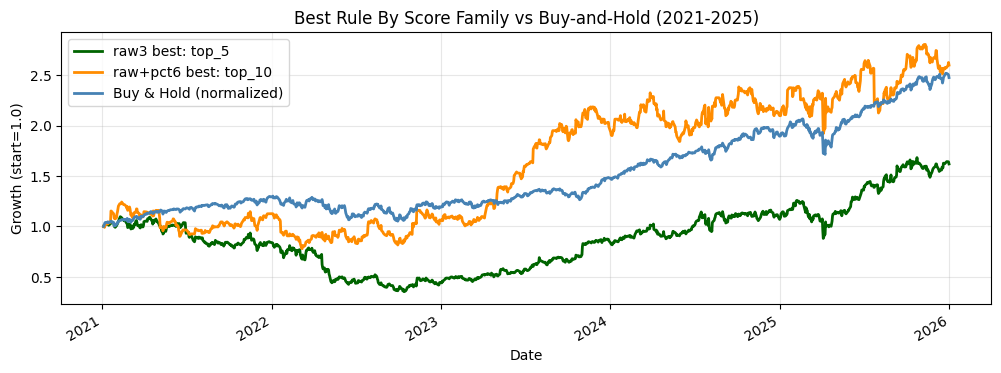

,bh_equity,bh_returns,raw3_best_equity,raw3_best_returns,raw_pct6_best_equity,raw_pct6_best_returns
date,,,,,,
2025-12-24,2.516327,0.004303,163260.945409,0.002300,257064.268104,-0.002898
2025-12-26,2.515012,-0.000523,164225.736510,0.005910,257683.547903,0.002409
2025-12-29,2.506219,-0.003496,164140.438287,-0.000519,259833.769619,0.008344
2025-12-30,2.498777,-0.002970,163934.765337,-0.001253,262597.652932,0.010637
2025-12-31,2.473441,-0.010139,161942.841215,-0.012151,260017.603723,-0.009825


In [11]:
score_variants = dict(BENCHMARK_CFG.get("score_variants") or {"selected": str(BENCHMARK_CFG["selection_score_col"])})
variant_runs = {}
comparison_rows = []

for variant_name, score_col in score_variants.items():
    component_cols = resolve_component_cols(score_col)
    all_eligible_rule = run_simple_buy_score_rule(
        panel=bt_panel_5y,
        score_col=str(score_col),
        component_cols=component_cols,
        component_threshold=float(BENCHMARK_CFG["component_threshold"]),
        price_col="close",
        rebalance_freq=BENCHMARK_CFG["rebalance_freq"],
        initial_balance=float(BENCHMARK_CFG["initial_balance"]),
        fee_bps=float(BENCHMARK_CFG["fee_bps"]),
        slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
    )
    all_eligible_eq = all_eligible_rule["equity"].rename("equity")
    all_eligible_ret = all_eligible_rule["returns"].rename("returns")
    all_eligible_summary = summarize_curve(all_eligible_ret, FROZEN_BT_YEARS, mode=f"{variant_name}_all_eligible")

    topk_runs = {}
    for top_k in (5, 10, 15, 20):
        run = run_top_k_buy_score_rule(
            panel=bt_panel_5y,
            score_col=str(score_col),
            component_cols=component_cols,
            component_threshold=float(BENCHMARK_CFG["component_threshold"]),
            price_col="close",
            top_k=int(top_k),
            rebalance_freq=BENCHMARK_CFG["rebalance_freq"],
            initial_balance=float(BENCHMARK_CFG["initial_balance"]),
            fee_bps=float(BENCHMARK_CFG["fee_bps"]),
            slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
        )
        topk_runs[int(top_k)] = {
            "run": run,
            "summary": summarize_curve(run["returns"].rename("returns"), FROZEN_BT_YEARS, mode=f"{variant_name}_top_{top_k}"),
        }

    variant_runs[str(variant_name)] = {
        "score_col": str(score_col),
        "component_cols": list(component_cols),
        "all_eligible": {"run": all_eligible_rule, "summary": all_eligible_summary},
        "topk": topk_runs,
    }

    print(f"Score variant: {variant_name} ({score_col})")
    print(f"Component columns: {component_cols}")
    print("Yearly OOS results: all eligible")
    display(all_eligible_summary["yearly_df"])
    print("Executed trade counts: all eligible")
    display(all_eligible_rule["executed_action_counts"].rename("count"))
    comparison_rows.append({
        "score_variant": str(variant_name),
        "score_col": str(score_col),
        "mode": "all_eligible",
        "total_return_pct": all_eligible_summary["total_return_pct"],
        "sharpe": all_eligible_summary["sharpe"],
        "max_drawdown_pct": all_eligible_summary["max_drawdown_pct"],
    })
    for top_k in sorted(topk_runs):
        print(f"Yearly OOS results: top {top_k}")
        display(topk_runs[top_k]["summary"]["yearly_df"])
        print(f"Executed trade counts: top {top_k}")
        display(topk_runs[top_k]["run"]["executed_action_counts"].rename("count"))
        comparison_rows.append({
            "score_variant": str(variant_name),
            "score_col": str(score_col),
            "mode": f"top_{top_k}",
            "total_return_pct": topk_runs[top_k]["summary"]["total_return_pct"],
            "sharpe": topk_runs[top_k]["summary"]["sharpe"],
            "max_drawdown_pct": topk_runs[top_k]["summary"]["max_drawdown_pct"],
        })

bh_strategy = BuyAndHoldEqualWeightStrategy(
    price_col="close",
    gross_exposure=1.0,
    top_k=None,
    liquidate_on_last_day=True,
)

first_variant = next(iter(variant_runs.values()))
reference_index = first_variant["all_eligible"]["run"]["equity"].index
bh_res = backtest_panel(panel=bt_panel_5y, strategy=bh_strategy, cfg=cfg)
bh_eq = bh_res.equity_curve.rename("equity").reindex(reference_index).ffill()
bh_ret = bh_res.returns.rename("returns").reindex(reference_index).fillna(0.0)
bh_summary = summarize_curve(bh_ret, FROZEN_BT_YEARS, mode="buy_and_hold_equal_weight_strategy")

print("Buy-and-hold yearly OOS results (strategy):")
display(bh_summary["yearly_df"])

comparison_df = pd.DataFrame(comparison_rows).sort_values(["total_return_pct", "sharpe"], ascending=[False, False]).reset_index(drop=True)
print("Signal rule comparison across score families (combined OOS):")
display(comparison_df)

best_by_variant_df = (
    comparison_df.sort_values(["score_variant", "total_return_pct", "sharpe"], ascending=[True, False, False])
    .groupby("score_variant", as_index=False)
    .first()
)
print("Best rule within each score family:")
display(best_by_variant_df)

comparison_with_bh_df = pd.concat([
    best_by_variant_df,
    pd.DataFrame([{
        "score_variant": "benchmark",
        "score_col": "buy_and_hold",
        "mode": "buy_and_hold_equal_weight_strategy",
        "total_return_pct": bh_summary["total_return_pct"],
        "sharpe": bh_summary["sharpe"],
        "max_drawdown_pct": bh_summary["max_drawdown_pct"],
    }]),
], ignore_index=True)
print("Best family-level recommendation vs buy-and-hold:")
display(comparison_with_bh_df)

raw3_best_mode = str(best_by_variant_df.loc[best_by_variant_df["score_variant"] == "raw3", "mode"].iloc[0]) if (best_by_variant_df["score_variant"] == "raw3").any() else "all_eligible"
rawpct6_best_mode = str(best_by_variant_df.loc[best_by_variant_df["score_variant"] == "raw_pct6", "mode"].iloc[0]) if (best_by_variant_df["score_variant"] == "raw_pct6").any() else "all_eligible"

def _equity_for_mode(variant_key, mode):
    if mode == "all_eligible":
        return variant_runs[variant_key]["all_eligible"]["run"]["equity"].rename("equity").reindex(reference_index).ffill()
    top_k = int(str(mode).split("_")[-1])
    return variant_runs[variant_key]["topk"][top_k]["run"]["equity"].rename("equity").reindex(reference_index).ffill()

raw3_best_eq = _equity_for_mode("raw3", raw3_best_mode) if "raw3" in variant_runs else None
rawpct6_best_eq = _equity_for_mode("raw_pct6", rawpct6_best_mode) if "raw_pct6" in variant_runs else None

fig, ax = plt.subplots(figsize=(12, 4))
if raw3_best_eq is not None:
    (raw3_best_eq / max(float(raw3_best_eq.iloc[0]), 1e-12)).plot(ax=ax, lw=2, label=f"raw3 best: {raw3_best_mode}", color="darkgreen")
if rawpct6_best_eq is not None:
    (rawpct6_best_eq / max(float(rawpct6_best_eq.iloc[0]), 1e-12)).plot(ax=ax, lw=2, label=f"raw+pct6 best: {rawpct6_best_mode}", color="darkorange")
(bh_eq / max(float(bh_eq.iloc[0]), 1e-12)).plot(ax=ax, lw=2, label="Buy & Hold (normalized)", color="steelblue")
ax.set_title(f"Best Rule By Score Family vs Buy-and-Hold ({FROZEN_BT_YEARS[0]}-{FROZEN_BT_YEARS[-1]})")
ax.set_xlabel("Date")
ax.set_ylabel("Growth (start=1.0)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

tail_df = pd.DataFrame({"bh_equity": bh_eq, "bh_returns": bh_ret})
if raw3_best_eq is not None:
    raw3_best_ret = variant_runs["raw3"]["all_eligible"]["run"]["returns"].rename("returns").reindex(reference_index).fillna(0.0) if raw3_best_mode == "all_eligible" else variant_runs["raw3"]["topk"][int(raw3_best_mode.split("_")[-1])]["run"]["returns"].rename("returns").reindex(reference_index).fillna(0.0)
    tail_df["raw3_best_equity"] = raw3_best_eq
    tail_df["raw3_best_returns"] = raw3_best_ret
if rawpct6_best_eq is not None:
    rawpct6_best_ret = variant_runs["raw_pct6"]["all_eligible"]["run"]["returns"].rename("returns").reindex(reference_index).fillna(0.0) if rawpct6_best_mode == "all_eligible" else variant_runs["raw_pct6"]["topk"][int(rawpct6_best_mode.split("_")[-1])]["run"]["returns"].rename("returns").reindex(reference_index).fillna(0.0)
    tail_df["raw_pct6_best_equity"] = rawpct6_best_eq
    tail_df["raw_pct6_best_returns"] = rawpct6_best_ret
display(tail_df.tail())


## J) Paper-Inspired Research Suite

This section treats the strategy as an open research question rather than assuming the current score is correct. Each block answers a different question inspired by time-series momentum, cross-sectional momentum, factor research, and characteristics-based ML research.

The goal is to separate timing, ranking quality, component roles, and portfolio construction so we can tell where any edge is really coming from.


In [12]:
# 9) Paper-inspired experiments: cross-sectional ranking, factor sleeves, ranking-vs-portfolio, sniper rules

PAPER_EXPERIMENT_CFG = {
    "cross_sectional_rebalance_freq": "M",
    "cross_sectional_forward_horizon_days": 21,
    "bucket_count": 5,
    "sniper_entry_threshold": 0.60,
    "sniper_exit_threshold": 0.40,
    "sniper_rebalance_freq": None,
}
print("Paper-inspired experiment config")
display(pd.DataFrame([PAPER_EXPERIMENT_CFG]))


def _pivot_panel(panel, col, symbols=None):
    working_symbols = sorted(panel.index.get_level_values("symbol").unique()) if symbols is None else list(symbols)
    return (
        panel[[col]]
        .reset_index()
        .pivot(index="date", columns="symbol", values=col)
        .reindex(columns=working_symbols)
        .sort_index()
    )


def _compute_cross_sectional_ranking_diagnostics(
    panel,
    *,
    score_col,
    variant_name,
    rebalance_freq,
    forward_horizon_days,
    bucket_count,
):
    symbols = sorted(panel.index.get_level_values("symbol").unique())
    close = _pivot_panel(panel, "close", symbols=symbols).replace([np.inf, -np.inf], np.nan).ffill()
    if score_col == "__momentum_21d__":
        score = close.pct_change(21)
    else:
        score = _pivot_panel(panel, score_col, symbols=symbols)
    score = score.shift(1).replace([np.inf, -np.inf], np.nan)
    forward_return = close.shift(-int(forward_horizon_days)).divide(close).subtract(1.0)
    common_dates = score.index.intersection(forward_return.index)
    rebalance_mask = make_rebalance_mask(common_dates, rebalance_freq)
    fold_rows = []
    bucket_rows = []

    for t, dt in enumerate(common_dates):
        if not bool(rebalance_mask[t]):
            continue
        aligned = pd.concat(
            {
                "score": pd.to_numeric(score.loc[dt], errors="coerce"),
                "forward_return": pd.to_numeric(forward_return.loc[dt], errors="coerce"),
            },
            axis=1,
        ).dropna()
        if len(aligned) < max(int(bucket_count) + 1, 8):
            continue
        aligned["bucket"] = np.ceil(
            aligned["score"].rank(method="first", pct=True) * float(bucket_count)
        ).clip(1, int(bucket_count)).astype(int)
        ic = aligned["score"].corr(aligned["forward_return"], method="spearman")
        top_bucket = aligned.loc[aligned["bucket"] == int(bucket_count), "forward_return"]
        bottom_bucket = aligned.loc[aligned["bucket"] == 1, "forward_return"]
        spread = float(top_bucket.mean() - bottom_bucket.mean()) if len(top_bucket) and len(bottom_bucket) else np.nan
        fold_rows.append(
            {
                "date": pd.Timestamp(dt),
                "variant_name": str(variant_name),
                "mean_spearman_ic": float(ic) if pd.notna(ic) else np.nan,
                "long_short_spread": spread,
                "top_bucket_forward_return": float(top_bucket.mean()) if len(top_bucket) else np.nan,
                "bottom_bucket_forward_return": float(bottom_bucket.mean()) if len(bottom_bucket) else np.nan,
                "symbols_ranked": int(len(aligned)),
            }
        )
        bucket_grouped = aligned.groupby("bucket", sort=True)["forward_return"].mean()
        for bucket_id, bucket_mean in bucket_grouped.items():
            bucket_rows.append(
                {
                    "variant_name": str(variant_name),
                    "bucket": int(bucket_id),
                    "mean_forward_return": float(bucket_mean),
                }
            )

    fold_df = pd.DataFrame(fold_rows)
    bucket_df = pd.DataFrame(bucket_rows)
    if fold_df.empty:
        summary_df = pd.DataFrame()
    else:
        summary_df = pd.DataFrame([
            {
                "variant_name": str(variant_name),
                "rebalance_freq": str(rebalance_freq),
                "forward_horizon_days": int(forward_horizon_days),
                "bucket_count": int(bucket_count),
                "mean_spearman_ic": float(fold_df["mean_spearman_ic"].mean()),
                "mean_long_short_spread": float(fold_df["long_short_spread"].mean()),
                "mean_top_bucket_forward_return": float(fold_df["top_bucket_forward_return"].mean()),
                "mean_bottom_bucket_forward_return": float(fold_df["bottom_bucket_forward_return"].mean()),
                "evaluation_dates": int(len(fold_df)),
                "mean_symbols_ranked": float(fold_df["symbols_ranked"].mean()),
            }
        ])
    if not bucket_df.empty:
        bucket_df = (
            bucket_df.groupby(["variant_name", "bucket"], as_index=False)["mean_forward_return"]
            .mean()
            .sort_values(["variant_name", "bucket"])
            .reset_index(drop=True)
        )
    return summary_df, bucket_df, fold_df




Paper-inspired experiment config


,cross_sectional_rebalance_freq,cross_sectional_forward_horizon_days,bucket_count,sniper_entry_threshold,sniper_exit_threshold,sniper_rebalance_freq
0,M,21,5,0.6,0.4,None


### J.1 Cross-Sectional Ranking Test

Question: do higher-scored names earn better forward returns than lower-scored names?

This is the closest analogue to cross-sectional momentum papers. It reports bucket forward returns, rank IC, and top-minus-bottom spread for `raw3`, `raw_pct6`, and a simple `21d` momentum baseline.


In [13]:
cross_sectional_specs = {
    "raw3": "buy_score_mean_raw3",
    "raw_pct6": "buy_score_mean_raw_pct6",
    "momentum_21d": "__momentum_21d__",
}
cs_summary_frames = []
cs_bucket_frames = []
cs_fold_frames = []
for variant_name, score_col in cross_sectional_specs.items():
    summary_df, bucket_df, fold_df = _compute_cross_sectional_ranking_diagnostics(
        bt_panel_5y,
        score_col=score_col,
        variant_name=variant_name,
        rebalance_freq=PAPER_EXPERIMENT_CFG["cross_sectional_rebalance_freq"],
        forward_horizon_days=int(PAPER_EXPERIMENT_CFG["cross_sectional_forward_horizon_days"]),
        bucket_count=int(PAPER_EXPERIMENT_CFG["bucket_count"]),
    )
    if not summary_df.empty:
        cs_summary_frames.append(summary_df)
    if not bucket_df.empty:
        cs_bucket_frames.append(bucket_df)
    if not fold_df.empty:
        cs_fold_frames.append(fold_df)

cs_summary_df = pd.concat(cs_summary_frames, ignore_index=True) if cs_summary_frames else pd.DataFrame()
cs_bucket_df = pd.concat(cs_bucket_frames, ignore_index=True) if cs_bucket_frames else pd.DataFrame()
cs_fold_df = pd.concat(cs_fold_frames, ignore_index=True) if cs_fold_frames else pd.DataFrame()
print("Cross-sectional momentum style ranking diagnostics")
display(cs_summary_df)
print("Cross-sectional bucket forward returns")
display(cs_bucket_df)




Cross-sectional momentum style ranking diagnostics


,variant_name,rebalance_freq,forward_horizon_days,bucket_count,mean_spearman_ic,mean_long_short_spread,mean_top_bucket_forward_return,mean_bottom_bucket_forward_return,evaluation_dates,mean_symbols_ranked
0,raw3,M,21,5,-0.009870,0.003740,0.016847,0.013107,59,109.372881
1,raw_pct6,M,21,5,0.002236,0.004862,0.018253,0.013391,59,109.372881
2,momentum_21d,M,21,5,0.020407,0.004005,0.020413,0.016408,58,110.810345


Cross-sectional bucket forward returns


,variant_name,bucket,mean_forward_return
0,raw3,1,0.013107
1,raw3,2,0.018279
2,raw3,3,0.022214
3,raw3,4,0.016744
4,raw3,5,0.016847
5,raw_pct6,1,0.013391
6,raw_pct6,2,0.015656
7,raw_pct6,3,0.019311
8,raw_pct6,4,0.020625
9,raw_pct6,5,0.018253


### J.2 Signal And Composite Role Test

Question: how should the model outputs be used?

`prob_buy` is treated as the direct signal, `pred_rf_reg` as a ranking modifier, and `ae_familiarity` as a confidence/filter term. This block tests whether simple role-aware composites are better than using the base signal alone.


In [14]:
factor_panel = bt_panel_5y.copy()
factor_panel["prob_buy_rankmod_rf"] = factor_panel[["prob_buy", "pred_rf_reg"]].mean(axis=1, skipna=True)
factor_panel["prob_buy_filter_ae"] = factor_panel["prob_buy"] * factor_panel["ae_familiarity"]
factor_panel["prob_buy_rankmod_rf_filter_ae"] = factor_panel[["prob_buy", "pred_rf_reg", "ae_familiarity"]].mean(axis=1, skipna=True)

factor_sleeve_specs = {
    "prob_buy_signal": "prob_buy",
    "prob_buy_plus_rf_rankmod": "prob_buy_rankmod_rf",
    "prob_buy_plus_ae_filter": "prob_buy_filter_ae",
    "prob_buy_plus_rf_plus_ae": "prob_buy_rankmod_rf_filter_ae",
    "raw3_factor": "buy_score_mean_raw3",
    "raw_pct6_factor": "buy_score_mean_raw_pct6",
}
factor_summary_frames = []
for variant_name, score_col in factor_sleeve_specs.items():
    summary_df, _, _ = _compute_cross_sectional_ranking_diagnostics(
        factor_panel,
        score_col=score_col,
        variant_name=variant_name,
        rebalance_freq=PAPER_EXPERIMENT_CFG["cross_sectional_rebalance_freq"],
        forward_horizon_days=int(PAPER_EXPERIMENT_CFG["cross_sectional_forward_horizon_days"]),
        bucket_count=int(PAPER_EXPERIMENT_CFG["bucket_count"]),
    )
    if not summary_df.empty:
        factor_summary_frames.append(summary_df)
factor_summary_df = pd.concat(factor_summary_frames, ignore_index=True) if factor_summary_frames else pd.DataFrame()
print("Fama-French style signal/composite diagnostics")
display(factor_summary_df)




Fama-French style signal/composite diagnostics


,variant_name,rebalance_freq,forward_horizon_days,bucket_count,mean_spearman_ic,mean_long_short_spread,mean_top_bucket_forward_return,mean_bottom_bucket_forward_return,evaluation_dates,mean_symbols_ranked
0,prob_buy_signal,M,21,5,-0.026350,-0.002358,0.015570,0.017928,59,109.372881
1,prob_buy_plus_rf_rankmod,M,21,5,-0.005261,0.005017,0.019390,0.014373,59,109.372881
2,prob_buy_plus_ae_filter,M,21,5,-0.027090,-0.004657,0.013341,0.017998,59,109.372881
3,prob_buy_plus_rf_plus_ae,M,21,5,-0.009870,0.003740,0.016847,0.013107,59,109.372881
4,raw3_factor,M,21,5,-0.009870,0.003740,0.016847,0.013107,59,109.372881
5,raw_pct6_factor,M,21,5,0.002236,0.004862,0.018253,0.013391,59,109.372881


### J.3 Portfolio Outcome Vs Ranking Quality

Question: is the winning portfolio rule actually backed by a better ranking signal, or is it just a lucky construction choice?

This block joins the best rule in each score family with the cross-sectional diagnostics so we can compare portfolio performance and ranking quality side by side.


In [15]:
characteristic_portfolio_diag_df = best_by_variant_df.merge(
    cs_summary_df[["variant_name", "mean_spearman_ic", "mean_long_short_spread", "mean_top_bucket_forward_return"]].rename(columns={"variant_name": "score_variant"}),
    on="score_variant",
    how="left",
)
print("Characteristics-factor style: portfolio outcome vs ranking quality")
display(characteristic_portfolio_diag_df)




Characteristics-factor style: portfolio outcome vs ranking quality


,score_variant,score_col,mode,total_return_pct,sharpe,max_drawdown_pct,mean_spearman_ic,mean_long_short_spread,mean_top_bucket_forward_return
0,raw3,buy_score_mean_raw3,top_5,61.942841,0.454366,-67.870283,-0.009870,0.003740,0.016847
1,raw_pct6,buy_score_mean_raw_pct6,top_10,160.017604,0.749363,-37.280021,0.002236,0.004862,0.018253


### J.4 Timing / Sniper Test

Question: does the score have per-symbol timing value when traded as an independent entry/exit rule?

This block uses asymmetric entry and exit thresholds to test whether the score works as a time-series-style sniper signal instead of only as a cross-sectional sorter.


In [16]:
def run_sniper_threshold_rule(
    *,
    panel,
    score_col,
    component_cols,
    entry_threshold,
    exit_threshold,
    price_col,
    rebalance_freq,
    initial_balance,
    fee_bps,
    slippage_bps,
):
    symbols = sorted(panel.index.get_level_values("symbol").unique())
    close = _pivot_panel(panel, price_col, symbols=symbols).replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)
    score = _pivot_panel(panel, score_col, symbols=symbols).shift(1).replace([np.inf, -np.inf], np.nan)
    common_dates = score.index.intersection(close.index)
    close = close.loc[common_dates]
    score = score.loc[common_dates]
    component_frames = []
    for col in component_cols:
        component = _pivot_panel(panel, col, symbols=symbols).shift(1).reindex(index=common_dates, columns=symbols)
        component_frames.append(component.replace([np.inf, -np.inf], np.nan))
    rebalance_mask = make_rebalance_mask(common_dates, rebalance_freq)
    action_type = np.zeros((len(common_dates), len(symbols)), dtype=int)
    held_idx = set()

    for t, dt in enumerate(common_dates):
        if not bool(rebalance_mask[t]):
            continue
        price_ok = close.loc[dt].gt(0.0)
        entry_ok = price_ok.copy()
        exit_trigger = ~price_ok
        for component in component_frames:
            comp_t = pd.to_numeric(component.loc[dt], errors="coerce")
            comp_valid = comp_t.notna() & np.isfinite(comp_t)
            entry_ok &= (comp_t > float(entry_threshold)) & comp_valid
            exit_trigger |= (~comp_valid) | (comp_t <= float(exit_threshold))
        entry_candidates = {symbols.index(sym) for sym in entry_ok[entry_ok].index}
        exit_idx = sorted(idx for idx in held_idx if bool(exit_trigger.iloc[idx]))
        retained_idx = set(idx for idx in held_idx if idx not in exit_idx)
        enter_idx = sorted(entry_candidates - retained_idx)
        if enter_idx:
            action_type[t, enter_idx] = 1
        if exit_idx:
            action_type[t, exit_idx] = 2
        held_idx = retained_idx | set(enter_idx)

    eq, ret, cash, details = backtest_strategy_per_stock_discrete(
        action_type=action_type,
        close_by_day=close,
        eligible_by_day=np.ones((len(common_dates), len(symbols)), dtype=bool),
        buy_score_by_day=score.fillna(0.0).to_numpy(dtype=float),
        initial_balance=float(initial_balance),
        fee_bps=float(fee_bps),
        slippage_bps=float(slippage_bps),
        max_buys_per_day=None,
        rebalance_mask=rebalance_mask,
        return_execution_stats=True,
        return_trade_log=True,
    )
    return {
        "equity": eq,
        "returns": ret,
        "trade_log": details.get("trade_log", pd.DataFrame()),
        "executed_action_counts": pd.Series({
            "buy": int(details.get("executed_buy_count", 0)),
            "sell": int(details.get("executed_sell_count", 0)),
        }, dtype=int),
    }


sniper_rows = []
for variant_name, score_col in {"raw3": "buy_score_mean_raw3", "raw_pct6": "buy_score_mean_raw_pct6"}.items():
    component_cols = resolve_component_cols(score_col)
    sniper_run = run_sniper_threshold_rule(
        panel=bt_panel_5y,
        score_col=score_col,
        component_cols=component_cols,
        entry_threshold=float(PAPER_EXPERIMENT_CFG["sniper_entry_threshold"]),
        exit_threshold=float(PAPER_EXPERIMENT_CFG["sniper_exit_threshold"]),
        price_col="close",
        rebalance_freq=PAPER_EXPERIMENT_CFG["sniper_rebalance_freq"],
        initial_balance=float(BENCHMARK_CFG["initial_balance"]),
        fee_bps=float(BENCHMARK_CFG["fee_bps"]),
        slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
    )
    sniper_summary = summarize_curve(sniper_run["returns"].rename("returns"), FROZEN_BT_YEARS, mode=f"{variant_name}_sniper")
    sniper_rows.append(
        {
            "score_variant": str(variant_name),
            "score_col": str(score_col),
            "mode": "sniper_rule",
            "entry_threshold": float(PAPER_EXPERIMENT_CFG["sniper_entry_threshold"]),
            "exit_threshold": float(PAPER_EXPERIMENT_CFG["sniper_exit_threshold"]),
            "total_return_pct": sniper_summary["total_return_pct"],
            "sharpe": sniper_summary["sharpe"],
            "max_drawdown_pct": sniper_summary["max_drawdown_pct"],
            "buy_count": int(sniper_run["executed_action_counts"].get("buy", 0)),
            "sell_count": int(sniper_run["executed_action_counts"].get("sell", 0)),
        }
    )
sniper_summary_df = pd.DataFrame(sniper_rows)
print("Time-series / sniper style threshold rule summary")
display(sniper_summary_df)



Time-series / sniper style threshold rule summary


,score_variant,score_col,mode,entry_threshold,exit_threshold,total_return_pct,sharpe,max_drawdown_pct,buy_count,sell_count
0,raw3,buy_score_mean_raw3,sniper_rule,0.6,0.4,127.565041,0.606396,-42.718653,184,183
1,raw_pct6,buy_score_mean_raw_pct6,sniper_rule,0.6,0.4,232.440000,0.912956,-36.538142,132,131


### J.5 raw_pct6 Robustness Sweep

Question: does the current leading score family (`raw_pct6`) still look good when we perturb the specification?

This block varies ranking settings, portfolio construction choices, and sniper thresholds so we can see whether the signal survives nearby design choices or only works in one narrow configuration.


In [17]:
raw_pct6_component_cols = resolve_component_cols("buy_score_mean_raw_pct6")

raw_pct6_ranking_rows = []
for rebalance_freq in ["W", "M"]:
    for horizon_days in [5, 21, 63]:
        for bucket_count in [5, 10]:
            summary_df, _, _ = _compute_cross_sectional_ranking_diagnostics(
                bt_panel_5y,
                score_col="buy_score_mean_raw_pct6",
                variant_name="raw_pct6",
                rebalance_freq=rebalance_freq,
                forward_horizon_days=int(horizon_days),
                bucket_count=int(bucket_count),
            )
            if summary_df.empty:
                continue
            row = dict(summary_df.iloc[0].to_dict())
            raw_pct6_ranking_rows.append(row)
raw_pct6_ranking_robustness_df = pd.DataFrame(raw_pct6_ranking_rows).sort_values(
    ["mean_long_short_spread", "mean_spearman_ic"], ascending=[False, False]
).reset_index(drop=True)
print("raw_pct6 ranking robustness grid")
display(raw_pct6_ranking_robustness_df)

raw_pct6_portfolio_rows = []
for rebalance_freq in [None, "W", "M"]:
    for threshold in [0.45, 0.50, 0.55]:
        all_run = run_simple_buy_score_rule(
            panel=bt_panel_5y,
            score_col="buy_score_mean_raw_pct6",
            component_cols=raw_pct6_component_cols,
            component_threshold=float(threshold),
            price_col="close",
            rebalance_freq=rebalance_freq,
            initial_balance=float(BENCHMARK_CFG["initial_balance"]),
            fee_bps=float(BENCHMARK_CFG["fee_bps"]),
            slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
        )
        all_summary = summarize_curve(all_run["returns"].rename("returns"), FROZEN_BT_YEARS, mode="raw_pct6_all_eligible")
        raw_pct6_portfolio_rows.append({
            "mode": "all_eligible",
            "rebalance_freq": rebalance_freq,
            "component_threshold": float(threshold),
            "total_return_pct": all_summary["total_return_pct"],
            "sharpe": all_summary["sharpe"],
            "max_drawdown_pct": all_summary["max_drawdown_pct"],
            "buy_count": int(all_run["executed_action_counts"].get("buy", 0)),
            "sell_count": int(all_run["executed_action_counts"].get("sell", 0)),
        })
        for top_k in [5, 10, 20]:
            top_run = run_top_k_buy_score_rule(
                panel=bt_panel_5y,
                score_col="buy_score_mean_raw_pct6",
                component_cols=raw_pct6_component_cols,
                component_threshold=float(threshold),
                price_col="close",
                top_k=int(top_k),
                rebalance_freq=rebalance_freq,
                initial_balance=float(BENCHMARK_CFG["initial_balance"]),
                fee_bps=float(BENCHMARK_CFG["fee_bps"]),
                slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
            )
            top_summary = summarize_curve(top_run["returns"].rename("returns"), FROZEN_BT_YEARS, mode=f"raw_pct6_top_{top_k}")
            raw_pct6_portfolio_rows.append({
                "mode": f"top_{top_k}",
                "rebalance_freq": rebalance_freq,
                "component_threshold": float(threshold),
                "total_return_pct": top_summary["total_return_pct"],
                "sharpe": top_summary["sharpe"],
                "max_drawdown_pct": top_summary["max_drawdown_pct"],
                "buy_count": int(top_run["executed_action_counts"].get("buy", 0)),
                "sell_count": int(top_run["executed_action_counts"].get("sell", 0)),
            })
raw_pct6_portfolio_robustness_df = pd.DataFrame(raw_pct6_portfolio_rows).sort_values(
    ["sharpe", "total_return_pct"], ascending=[False, False]
).reset_index(drop=True)
print("raw_pct6 portfolio construction robustness grid")
display(raw_pct6_portfolio_robustness_df)

raw_pct6_sniper_rows = []
for rebalance_freq in [None, "W", "M"]:
    for entry_threshold, exit_threshold in [(0.55, 0.45), (0.60, 0.40), (0.65, 0.35)]:
        sniper_run = run_sniper_threshold_rule(
            panel=bt_panel_5y,
            score_col="buy_score_mean_raw_pct6",
            component_cols=raw_pct6_component_cols,
            entry_threshold=float(entry_threshold),
            exit_threshold=float(exit_threshold),
            price_col="close",
            rebalance_freq=rebalance_freq,
            initial_balance=float(BENCHMARK_CFG["initial_balance"]),
            fee_bps=float(BENCHMARK_CFG["fee_bps"]),
            slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
        )
        sniper_sum = summarize_curve(sniper_run["returns"].rename("returns"), FROZEN_BT_YEARS, mode="raw_pct6_sniper")
        raw_pct6_sniper_rows.append({
            "rebalance_freq": rebalance_freq,
            "entry_threshold": float(entry_threshold),
            "exit_threshold": float(exit_threshold),
            "total_return_pct": sniper_sum["total_return_pct"],
            "sharpe": sniper_sum["sharpe"],
            "max_drawdown_pct": sniper_sum["max_drawdown_pct"],
            "buy_count": int(sniper_run["executed_action_counts"].get("buy", 0)),
            "sell_count": int(sniper_run["executed_action_counts"].get("sell", 0)),
        })
raw_pct6_sniper_robustness_df = pd.DataFrame(raw_pct6_sniper_rows).sort_values(
    ["sharpe", "total_return_pct"], ascending=[False, False]
).reset_index(drop=True)
print("raw_pct6 sniper robustness grid")
display(raw_pct6_sniper_robustness_df)


raw_pct6 ranking robustness grid


,variant_name,rebalance_freq,forward_horizon_days,bucket_count,mean_spearman_ic,mean_long_short_spread,mean_top_bucket_forward_return,mean_bottom_bucket_forward_return,evaluation_dates,mean_symbols_ranked
0,raw_pct6,M,63,10,0.038651,0.035680,0.073327,0.037647,57,109.350877
1,raw_pct6,W,63,10,0.054827,0.031676,0.065995,0.034319,247,109.340081
2,raw_pct6,W,63,5,0.054827,0.025116,0.062285,0.037169,247,109.340081
3,raw_pct6,M,63,5,0.038651,0.020165,0.059379,0.039214,57,109.350877
4,raw_pct6,W,21,10,0.023330,0.009921,0.021638,0.011718,256,109.367188
5,raw_pct6,M,21,10,0.002236,0.008315,0.021994,0.013679,59,109.372881
6,raw_pct6,W,21,5,0.023330,0.008143,0.020752,0.012610,256,109.367188
7,raw_pct6,M,21,5,0.002236,0.004862,0.018253,0.013391,59,109.372881
8,raw_pct6,W,5,10,0.019811,0.003870,0.006289,0.002418,259,109.378378
9,raw_pct6,W,5,5,0.019811,0.002473,0.005622,0.003148,259,109.378378


raw_pct6 portfolio construction robustness grid


,mode,rebalance_freq,component_threshold,total_return_pct,sharpe,max_drawdown_pct,buy_count,sell_count
0,top_10,W,0.45,440.906730,1.375830,-27.437800,798,795
1,top_5,W,0.45,478.693232,1.367579,-24.244961,615,611
2,all_eligible,W,0.45,404.385182,1.338297,-25.652885,793,790
3,top_20,W,0.45,398.120761,1.325607,-26.177995,800,797
4,top_5,M,0.55,552.296480,1.297734,-33.892067,89,89
5,all_eligible,M,0.55,438.726002,1.210691,-33.892067,107,107
6,top_20,M,0.55,438.726002,1.210691,-33.892067,107,107
7,top_10,M,0.55,437.381716,1.207595,-33.892067,102,102
8,top_5,M,0.50,392.709868,1.175456,-25.334341,151,148
9,top_5,M,0.45,327.901945,1.171398,-25.454129,195,190


raw_pct6 sniper robustness grid


,rebalance_freq,entry_threshold,exit_threshold,total_return_pct,sharpe,max_drawdown_pct,buy_count,sell_count
0,W,0.65,0.35,269.063801,1.193292,-23.466214,44,44
1,M,0.55,0.45,382.603190,1.183948,-34.981142,95,95
2,W,0.55,0.45,428.375277,1.110738,-34.337173,190,189
3,NaN,0.65,0.35,204.463732,0.970727,-33.291813,60,60
4,NaN,0.60,0.40,232.440000,0.912956,-36.538142,132,131
5,M,0.60,0.40,185.699233,0.897678,-26.770849,37,37
6,NaN,0.55,0.45,170.826899,0.767445,-36.804591,293,292
7,W,0.60,0.40,124.718697,0.664892,-42.117838,87,85
8,M,0.65,0.35,-1.828057,0.133335,-55.961285,16,16


### J.6 Confirmation Set

This section freezes a small candidate list from the earlier research tables and evaluates those candidates on two slices of the same OOS block:

- `selection_years = 2021-2023`: the part of the OOS window we have implicitly been using to learn which ideas look promising
- `confirmation_years = 2024-2025`: a smaller confirmation slice used to check whether the short list still behaves well after we stop scanning large parameter grids

The candidates are intentionally fixed and small:

- `raw_pct6` weekly `top_5` with component threshold `0.45`
- `raw_pct6` monthly `top_5` with component threshold `0.55`
- `raw_pct6` weekly sniper with entry / exit thresholds `0.65 / 0.35`
- simple `21d` momentum weekly `top_5` as a non-ML control
- buy-and-hold equal weight as the broad-market control

This is still not a fully untouched out-of-sample test, but it is a cleaner confirmation step than continuing to optimize across the whole 2021-2025 window.


Confirmation experiment config


,selection_years,confirmation_years,candidate_count
0,2021-2023,2024-2025,5


Confirmation candidate summary


,candidate_name,kind,selection_total_return_pct,selection_sharpe,selection_max_drawdown_pct,confirmation_total_return_pct,confirmation_sharpe,confirmation_max_drawdown_pct,full_oos_total_return_pct,full_oos_sharpe,full_oos_max_drawdown_pct,buy_count,sell_count
0,buy_and_hold_equal_weight,benchmark,48.107064,0.905394,-19.143256,67.170608,1.718424,-17.052738,147.591479,1.227943,-19.143256,NaN,NaN
1,momentum21d_weekly_top5,top_k,10.744486,0.261591,-36.589730,166.782275,1.571359,-31.062693,195.446661,0.862006,-36.589730,454.0,450.0
2,raw_pct6_weekly_top5_thr045,top_k,171.410159,1.313477,-23.523069,113.217233,1.447083,-24.244961,478.693232,1.367579,-24.244961,615.0,611.0
3,raw_pct6_monthly_top5_thr055,top_k,260.866401,1.544745,-25.469673,80.758441,0.995316,-33.892067,552.296480,1.297734,-33.892067,89.0,89.0
4,raw_pct6_weekly_sniper_065_035,sniper,185.637427,1.630567,-18.164134,29.207088,0.620016,-23.466214,269.063801,1.193292,-23.466214,44.0,44.0


Confirmation candidate yearly breakdown


,mode,test_year,total_return_pct,sharpe,max_drawdown_pct,candidate_name,window
0,buy_and_hold_equal_weight_confirmation,2024,27.884340,2.046379,-7.341350,buy_and_hold_equal_weight,confirmation
1,buy_and_hold_equal_weight_confirmation,2025,30.720156,1.552596,-17.052738,buy_and_hold_equal_weight,confirmation
2,momentum21d_weekly_top5_confirmation,2024,136.408842,2.686018,-13.450330,momentum21d_weekly_top5,confirmation
3,momentum21d_weekly_top5_confirmation,2025,12.847842,0.518840,-31.062693,momentum21d_weekly_top5,confirmation
4,raw_pct6_monthly_top5_thr055_confirmation,2024,16.083612,0.605650,-23.164958,raw_pct6_monthly_top5_thr055,confirmation
5,raw_pct6_monthly_top5_thr055_confirmation,2025,55.714004,1.345791,-30.836837,raw_pct6_monthly_top5_thr055,confirmation
6,raw_pct6_weekly_sniper_065_035_confirmation,2024,-12.430518,-0.436125,-21.721398,raw_pct6_weekly_sniper_065_035,confirmation
7,raw_pct6_weekly_sniper_065_035_confirmation,2025,47.548077,1.522740,-13.507368,raw_pct6_weekly_sniper_065_035,confirmation
8,raw_pct6_weekly_top5_thr045_confirmation,2024,44.657774,1.489022,-16.530090,raw_pct6_weekly_top5_thr045,confirmation
9,raw_pct6_weekly_top5_thr045_confirmation,2025,47.394245,1.415398,-24.244961,raw_pct6_weekly_top5_thr045,confirmation


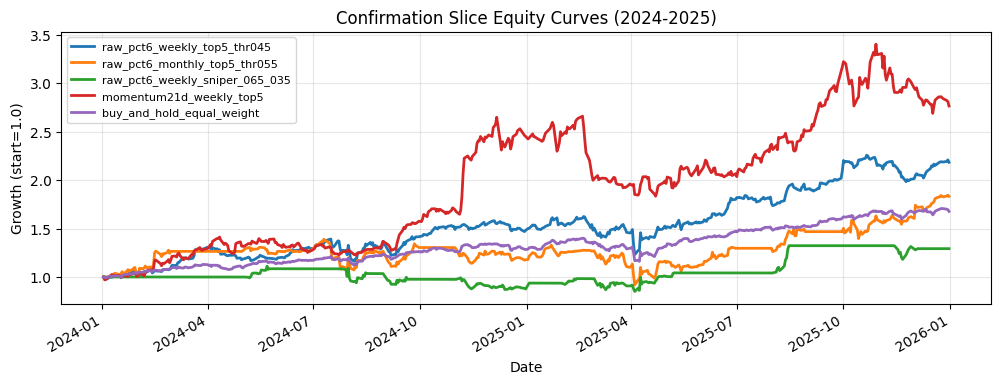

In [18]:
CONFIRMATION_CFG = {
    "selection_years": [2021, 2022, 2023],
    "confirmation_years": [2024, 2025],
}
print("Confirmation experiment config")
display(pd.DataFrame([{
    "selection_years": "2021-2023",
    "confirmation_years": "2024-2025",
    "candidate_count": 5,
}]))

confirmation_panel = bt_panel_5y.copy()
confirmation_panel["momentum_21d_signal"] = (
    confirmation_panel.groupby(level="symbol")["close"].pct_change(21)
)

confirmation_candidates = [
    {
        "candidate_name": "raw_pct6_weekly_top5_thr045",
        "kind": "top_k",
        "score_col": "buy_score_mean_raw_pct6",
        "component_cols": resolve_component_cols("buy_score_mean_raw_pct6"),
        "component_threshold": 0.45,
        "rebalance_freq": "W",
        "top_k": 5,
    },
    {
        "candidate_name": "raw_pct6_monthly_top5_thr055",
        "kind": "top_k",
        "score_col": "buy_score_mean_raw_pct6",
        "component_cols": resolve_component_cols("buy_score_mean_raw_pct6"),
        "component_threshold": 0.55,
        "rebalance_freq": "M",
        "top_k": 5,
    },
    {
        "candidate_name": "raw_pct6_weekly_sniper_065_035",
        "kind": "sniper",
        "score_col": "buy_score_mean_raw_pct6",
        "component_cols": resolve_component_cols("buy_score_mean_raw_pct6"),
        "entry_threshold": 0.65,
        "exit_threshold": 0.35,
        "rebalance_freq": "W",
    },
    {
        "candidate_name": "momentum21d_weekly_top5",
        "kind": "top_k",
        "score_col": "momentum_21d_signal",
        "component_cols": [],
        "component_threshold": 0.0,
        "rebalance_freq": "W",
        "top_k": 5,
    },
    {
        "candidate_name": "buy_and_hold_equal_weight",
        "kind": "benchmark",
    },
]


def _slice_returns(returns, years):
    year_set = {int(y) for y in years}
    return returns.loc[returns.index.year.map(int).isin(year_set)]


confirmation_rows = []
confirmation_yearly_frames = []
confirmation_curve_map = {}

for spec in confirmation_candidates:
    candidate_name = str(spec["candidate_name"])
    if spec["kind"] == "top_k":
        run = run_top_k_buy_score_rule(
            panel=confirmation_panel,
            score_col=str(spec["score_col"]),
            component_cols=list(spec.get("component_cols", [])),
            component_threshold=float(spec.get("component_threshold", 0.0)),
            price_col="close",
            top_k=int(spec["top_k"]),
            rebalance_freq=spec.get("rebalance_freq"),
            initial_balance=float(BENCHMARK_CFG["initial_balance"]),
            fee_bps=float(BENCHMARK_CFG["fee_bps"]),
            slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
        )
        returns = run["returns"].rename("returns")
        executed_counts = run.get("executed_action_counts", pd.Series(dtype=float))
    elif spec["kind"] == "sniper":
        run = run_sniper_threshold_rule(
            panel=confirmation_panel,
            score_col=str(spec["score_col"]),
            component_cols=list(spec.get("component_cols", [])),
            entry_threshold=float(spec["entry_threshold"]),
            exit_threshold=float(spec["exit_threshold"]),
            price_col="close",
            rebalance_freq=spec.get("rebalance_freq"),
            initial_balance=float(BENCHMARK_CFG["initial_balance"]),
            fee_bps=float(BENCHMARK_CFG["fee_bps"]),
            slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
        )
        returns = run["returns"].rename("returns")
        executed_counts = run.get("executed_action_counts", pd.Series(dtype=float))
    elif spec["kind"] == "benchmark":
        returns = bh_ret.rename("returns")
        executed_counts = pd.Series({"buy": np.nan, "sell": np.nan}, dtype=float)
    else:
        raise ValueError(f"Unsupported candidate kind: {spec['kind']}")

    full_summary = summarize_curve(returns, FROZEN_BT_YEARS, mode=candidate_name)
    selection_returns = _slice_returns(returns, CONFIRMATION_CFG["selection_years"])
    confirmation_returns = _slice_returns(returns, CONFIRMATION_CFG["confirmation_years"])
    selection_summary = summarize_curve(selection_returns, CONFIRMATION_CFG["selection_years"], mode=f"{candidate_name}_selection")
    confirmation_summary = summarize_curve(confirmation_returns, CONFIRMATION_CFG["confirmation_years"], mode=f"{candidate_name}_confirmation")

    confirmation_rows.append({
        "candidate_name": candidate_name,
        "kind": spec["kind"],
        "selection_total_return_pct": selection_summary["total_return_pct"],
        "selection_sharpe": selection_summary["sharpe"],
        "selection_max_drawdown_pct": selection_summary["max_drawdown_pct"],
        "confirmation_total_return_pct": confirmation_summary["total_return_pct"],
        "confirmation_sharpe": confirmation_summary["sharpe"],
        "confirmation_max_drawdown_pct": confirmation_summary["max_drawdown_pct"],
        "full_oos_total_return_pct": full_summary["total_return_pct"],
        "full_oos_sharpe": full_summary["sharpe"],
        "full_oos_max_drawdown_pct": full_summary["max_drawdown_pct"],
        "buy_count": executed_counts.get("buy", np.nan),
        "sell_count": executed_counts.get("sell", np.nan),
    })

    selection_yearly = selection_summary["yearly_df"].assign(candidate_name=candidate_name, window="selection")
    confirmation_yearly = confirmation_summary["yearly_df"].assign(candidate_name=candidate_name, window="confirmation")
    confirmation_yearly_frames.extend([selection_yearly, confirmation_yearly])
    confirmation_curve_map[candidate_name] = confirmation_returns

confirmation_summary_df = pd.DataFrame(confirmation_rows).sort_values(
    ["confirmation_sharpe", "confirmation_total_return_pct"],
    ascending=[False, False],
).reset_index(drop=True)
confirmation_yearly_df = pd.concat(confirmation_yearly_frames, ignore_index=True) if confirmation_yearly_frames else pd.DataFrame()

print("Confirmation candidate summary")
display(confirmation_summary_df)
print("Confirmation candidate yearly breakdown")
display(confirmation_yearly_df.sort_values(["window", "candidate_name", "test_year"]).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 4))
for candidate_name, candidate_returns in confirmation_curve_map.items():
    if len(candidate_returns) == 0:
        continue
    candidate_equity = (1.0 + candidate_returns).cumprod()
    candidate_equity = candidate_equity / max(float(candidate_equity.iloc[0]), 1e-12)
    candidate_equity.plot(ax=ax, lw=2, label=candidate_name)
ax.set_title("Confirmation Slice Equity Curves (2024-2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth (start=1.0)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.show()
